In [ ]:
from pathlib import Path
from typing import Any, Literal

import matplotlib.lines as mlines
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from dask.distributed import Client

from rojak.core.constants import TWENTIES_CLIMATOLOGICAL_PARAMETER
from rojak.core.data import shift_longitude
from rojak.core.indexing import concat_new_dim
from rojak.orchestrator.configuration import (
    RelationshipBetweenTypes,
    TurbulenceDiagnostics,
)
from rojak.orchestrator.lite_controller import (
    load_distribution_parameters_from_file,
    open_diagnostic_zarr,
)
from rojak.plot.utilities import StandardColourMaps, get_a_default_cmap
from rojak.turbulence.analysis import RelationshipBetweenXAndTurbulence, TransformToEDR
from rojak.turbulence.metrics import conditional_odds_ratio

## Helper functions

In [2]:
def sel_for_season[T: (xr.Dataset, xr.DataArray)](
    target_data: T,
    season: Literal["DJF", "MAM", "JJA", "SON"],
    time_dim_name: str = "time",
) -> T:
    return target_data.isel(
        indexers={time_dim_name: (target_data[time_dim_name].dt.season == season)}
    )

In [3]:
def sel_hemisphere[T: (xr.Dataset, xr.DataArray)](
    target_data: T,
    hemisphere: Literal["NH", "SH"],
    mid_lat_cut_off: float = 30,
) -> T:
    lat_slice = (
        slice(70, mid_lat_cut_off)
        if hemisphere == "NH"
        else slice(-mid_lat_cut_off, -70)
    )
    return target_data.sel(latitude=lat_slice)

In [4]:
def map_conditional_odds_on_turb(
    is_turb_da: xr.DataArray,
    effect_of: xr.DataArray,
    *control_var: xr.DataArray,
    sum_over: list[str] | None = None,
    use_log: bool = True,
    new_dim_name: str = "concat_dim",
    dim_values: list[Any] | None = None,
) -> xr.DataArray:
    if dim_values is None:
        target_length = (
            2 if (control_var_len := len(control_var)) == 1 else control_var_len
        )
        dim_values = np.arange(target_length).tolist()

    return concat_new_dim(
        conditional_odds_ratio(
            effect_of, is_turb_da, *control_var, sum_over=sum_over, use_log=use_log
        ),
        dim_name=new_dim_name,
        dim_values=dim_values,
    )

In [5]:
def load_single_level_data(target_path: Path, target_var: str) -> xr.DataArray:
    loaded_ds: xr.Dataset = xr.open_mfdataset(
        str(target_path / "*.nc"),
        chunks={"pressure_level": 6, "latitude": 721, "longitude": 1440},
        parallel=True,
        engine="h5netcdf",
        decode_coords=True,
        decode_cf=True,
        decode_timedelta=True,
    ).rename({"valid_time": "time"})
    return shift_longitude(loaded_ds[target_var])

In [6]:
def compute_vertical_velocity_masks(
    vertical_velocities: xr.DataArray, pressure_levels: xr.DataArray
) -> list[xr.DataArray]:
    all_thresholds = [-0.22, -0.03, 0.03, 0.22]
    masks = []
    for i in range(len(all_thresholds) + 1):
        if i == 0:
            # Velocities < minimum threshold
            condition = vertical_velocities < all_thresholds[0]
        elif i == len(all_thresholds):
            # Velocities >= maximum threshold
            condition = vertical_velocities >= all_thresholds[-1]
        else:
            # Velocities between two thresholds
            condition = (vertical_velocities >= all_thresholds[i - 1]) & (
                vertical_velocities < all_thresholds[i]
            )

        masks.append(
            condition.isel(pressure_level=0)
            .expand_dims(dim={"pressure_level": pressure_levels})
            .assign_coords({"pressure_level": pressure_levels})
        )
    return masks

In [7]:
def case_labels_vertical_velocity_thresholds(as_latex: bool = False) -> list[str]:
    all_thresholds = [-0.22, -0.03, 0.03, 0.22]
    labels = []
    leq = " \\leq " if as_latex else "<="
    geq = " \\geq " if as_latex else ">="

    for i in range(len(all_thresholds) + 1):
        if i == 0:
            # First bin: w < minimum
            labels.append(f"w<{all_thresholds[0]}")
        elif i == len(all_thresholds):
            # Last bin: w >= maximum
            labels.append(f"w{geq}{all_thresholds[-1]}")
        else:
            # Middle bins: threshold[i-1] <= w < threshold[i]
            lower = all_thresholds[i - 1]
            upper = all_thresholds[i]
            labels.append(f"{lower}{leq}w<{upper}")

    if as_latex:
        labels = [f"${item}$" for item in labels]

    return labels

## Constants

The `TARGET_SEASON` and `TARGET_HEMISPHERE` are changed to get the 4 permutations. This is done manually instead of a loop as memory is the limiting factor when running this locally.

In [8]:
TARGET_SEASON = "DJF"
TARGET_HEMISPHERE = "SH"
EDR_THRESHOLD: float = 0.22

In [9]:
client = Client()

## Recompute latitudinal marginal

As this is for the full study period (2023-2025), this is pre-computed for performance reasons. Uncomment to do the re-computation.

In [ ]:
# lat_mean_dims = ["time", "longitude"]

# base_path = Path("/path/to/exported/diagnostics")
# target_diagnostics = [
#     # TurbulenceDiagnostics.NCSU1,
#     # TurbulenceDiagnostics.TI1,
#     TurbulenceDiagnostics.BROWN2,
# ]
# diagnostics = {
#     target_diagnostic: open_diagnostic_zarr(
#         base_path / f"{target_diagnostic}.zarr", target_diagnostic
#     )
#     for target_diagnostic in target_diagnostics
# }
# dist_params_file = Path(
#     "/path/to/distribution_params.json"
# )
# distribution_parameters = load_distribution_parameters_from_file(dist_params_file)

In [11]:
# is_turb = {
#     target_diagnostic: (
#         TransformToEDR(
#             diagnostics[target_diagnostic],
#             c1=TWENTIES_CLIMATOLOGICAL_PARAMETER.c1,
#             c2=TWENTIES_CLIMATOLOGICAL_PARAMETER.c2,
#             mean=distribution_parameters[str(target_diagnostic)].mean,
#             variance=distribution_parameters[str(target_diagnostic)].variance,
#         ).execute()
#         > EDR_THRESHOLD
#     ).persist()
#     for target_diagnostic in target_diagnostics
# }

In [ ]:
# issr_base_path = Path("/path/to/issr")
# iss_regions = xr.open_zarr(issr_base_path / "issr.zarr", chunks="auto")["issr"]

In [13]:
# marginal_case = RelationshipBetweenXAndTurbulence(
#     iss_regions,
#     xr.Dataset(data_vars=is_turb),
#     RelationshipBetweenTypes.SAMPLE_ODDS_RATIO,
#     sum_over_dim=lat_mean_dims,
# ).execute()


In [14]:
# by_pl = marginal_case.compute()

In [ ]:
# marginal_case.to_zarr(
#     "/path/to/exported/marginal-odds-ratio.zarr", mode="w", zarr_format=2
# )

## Compute diff from marginal

### Load data

Import the required data and compute the necessary variables for computing $\vartheta$

In [ ]:
dist_params_file = Path("/path/to/distribution_params.json")
distribution_parameters = load_distribution_parameters_from_file(dist_params_file)

base_path = Path("/path/to/exported/diagnostics")
target_diagnostics = [
    TurbulenceDiagnostics.NCSU1,
    TurbulenceDiagnostics.TI1,
    TurbulenceDiagnostics.BROWN2,
]
diagnostics = {
    target_diagnostic: sel_hemisphere(
        sel_for_season(
            open_diagnostic_zarr(
                base_path / f"{target_diagnostic}.zarr", target_diagnostic
            ),
            TARGET_SEASON,
        ),
        TARGET_HEMISPHERE,
    ).sel(pressure_level=slice(300, 200))
    for target_diagnostic in target_diagnostics
}
is_turb = {
    target_diagnostic: (
        TransformToEDR(
            diagnostics[target_diagnostic],
            c1=TWENTIES_CLIMATOLOGICAL_PARAMETER.c1,
            c2=TWENTIES_CLIMATOLOGICAL_PARAMETER.c2,
            mean=distribution_parameters[str(target_diagnostic)].mean,
            variance=distribution_parameters[str(target_diagnostic)].variance,
        ).execute()
        > EDR_THRESHOLD
    )
    for target_diagnostic in target_diagnostics
}

In [ ]:
issr_base_path = Path("/path/to/issr")
iss_regions = sel_hemisphere(
    sel_for_season(
        xr.open_zarr(issr_base_path / "issr.zarr", chunks="auto")["issr"],
        TARGET_SEASON,
    ),
    TARGET_HEMISPHERE,
)

In [ ]:
w_path = Path(f"/path/to/era5_data/vertical-velocity/{TARGET_SEASON.lower()}-2023-2025")
vertical_velocity = load_single_level_data(w_path, "w")
vertical_velocity = sel_hemisphere(vertical_velocity, TARGET_HEMISPHERE).persist()

In [ ]:
marginal_case = sel_hemisphere(
    xr.open_zarr(
        "/path/to/exported-marginal-odds-ratio/marginal-odds-ratio-combined.zarr"
    ),
    TARGET_HEMISPHERE,
)

In [20]:
sum_over_dims = ["time", "longitude"]

### Compute $\vartheta$

In [ ]:
turb_as_ds = xr.Dataset(data_vars=is_turb)
dim_names = case_labels_vertical_velocity_thresholds()
vertical = compute_vertical_velocity_masks(
    vertical_velocity, is_turb[target_diagnostics[0]]["pressure_level"]
)
marginal_sign = np.sign(marginal_case)
season_marginal_case = (
    RelationshipBetweenXAndTurbulence(
        iss_regions,
        turb_as_ds,
        RelationshipBetweenTypes.SAMPLE_ODDS_RATIO,
        sum_over_dim=sum_over_dims,
    )
    .execute()
    .assign_coords({"conditions": "marginal"})
)
conditional_odds_of_cases = turb_as_ds.map(
    map_conditional_odds_on_turb,
    keep_attrs=False,
    args=[iss_regions, *vertical],
    sum_over=sum_over_dims,
    use_log=True,
    new_dim_name="conditions",
    dim_values=dim_names,
)
all_odds_ratios = xr.concat(
    [conditional_odds_of_cases, season_marginal_case], dim="conditions"
)

difference = marginal_sign * (all_odds_ratios - marginal_case)

### Plot $\vartheta$

For a visual sanity check that it matches the results from the previously HPC computed plots and that mean looks correct.

In [23]:
COOL_WARM_CMAP = get_a_default_cmap(
    StandardColourMaps.CORRELATION_COOL_WARM, load_kwargs={"cmap_type": "continuous"}
).resampled(18)

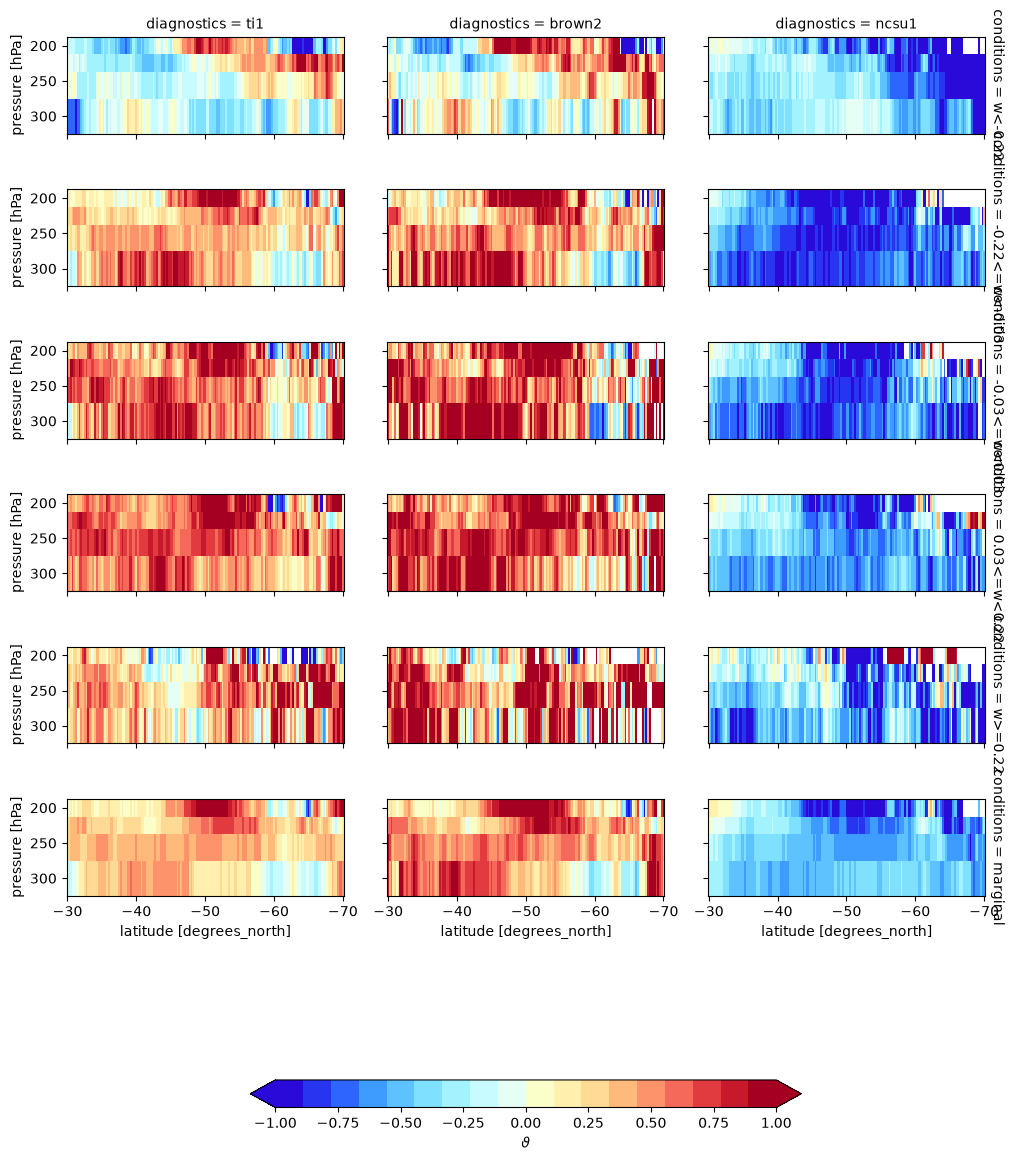

In [ ]:
fg = difference.to_dataarray("diagnostics").plot(
    row="conditions",
    col="diagnostics",
    x="latitude",
    cbar_kwargs={
        "orientation": "horizontal",
        "spacing": "uniform",
        "shrink": 0.6,
        "label": "$\\vartheta$",
    },
    robust=True,
    center=0,
    rasterized=True,
    vmax=1,
    vmin=-1,
    cmap=COOL_WARM_CMAP,
    col_wrap=3,
    yincrease=False,
    aspect=1.4,
    size=2.2,
    xincrease=False,
)

### Table Stats

In [25]:
mean_across_latitudes = difference.mean(
    dim=["latitude", "pressure_level"], skipna=True
).compute()

print(f"Season: {TARGET_SEASON}, Hemisphere: {TARGET_HEMISPHERE}")
print(f"Conditions: {difference['conditions'].values}")
print()
for key, value in mean_across_latitudes.items():
    print(f"{key}: {value.values}")

Season: DJF, Hemisphere: SH
Conditions: ['w<-0.22' '-0.22<=w<-0.03' '-0.03<=w<0.03' '0.03<=w<0.22' 'w>=0.22'
 'marginal']

ti1: [-0.04894082  0.34789541  0.52385996  0.570485    0.36282728  0.32848961]
brown2: [0.11194468 0.46610607 0.63553213 0.69644866 0.64290868 0.44836838]
ncsu1: [-0.55439468 -0.76624932 -0.64979745 -0.50386858 -0.4289333  -0.5168318 ]


## Collate Results ($25^\circ$ onwards)

### DJF - NH

```python
Conditions: ['w<-0.22' '-0.22<=w<-0.03' '-0.03<=w<0.03' '0.03<=w<0.22' 'w>=0.22' 'marginal']

ti1: [-0.49122698 -0.16518594 -0.17844123 -0.19668926 -0.28393184 -0.30328505]
brown2: [-0.4699267  -0.23183667 -0.27200976 -0.30352595 -0.3296208  -0.35275525]
ncsu1: [ 0.27021039 -0.06877204 -0.01166077  0.03319941 -0.07343943  0.19841459]
```

### DJF - SH

```python
Conditions: ['w<-0.22' '-0.22<=w<-0.03' '-0.03<=w<0.03' '0.03<=w<0.22' 'w>=0.22'
 'marginal']

ti1: [-0.08096823  0.32108286  0.49912036  0.54538757  0.33807973  0.29363482]
brown2: [0.07182792 0.45018574 0.61544149 0.69289678 0.62675692 0.42756408]
ncsu1: [-0.51084982 -0.70508365 -0.59473435 -0.4579662  -0.40452952 -0.45276677]
```

### JJA - NH

Season: JJA, Hemisphere: NH

```python
Conditions: ['w<-0.22' '-0.22<=w<-0.03' '-0.03<=w<0.03' '0.03<=w<0.22' 'w>=0.22'
 'marginal']

ti1: [0.051955   0.24083208 0.39323019 0.42524812 0.28922889 0.2409777 ]
brown2: [0.43225065 0.50392626 0.58497345 0.68555936 0.74553446 0.54109986]
ncsu1: [-0.18428619 -0.58820845 -0.59182034 -0.53299172 -0.3075436  -0.35481699]
```

### JJA - SH

Season: JJA, Hemisphere: SH

```python
Conditions: ['w<-0.22' '-0.22<=w<-0.03' '-0.03<=w<0.03' '0.03<=w<0.22' 'w>=0.22'
 'marginal']

ti1: [-0.61241499 -0.19522461 -0.12575627 -0.18303276 -0.38639546 -0.34341521]
brown2: [-0.6423629  -0.28338826 -0.19949273 -0.28382244 -0.44910732 -0.4159001 ]
ncsu1: [ 0.25513663 -0.02292296  0.11296884  0.36646041  0.63311293  0.33202582]
```

## Collate Results ($30^\circ$ onwards)

Season: JJA, Hemisphere: SH
```python
Conditions: ['w<-0.22' '-0.22<=w<-0.03' '-0.03<=w<0.03' '0.03<=w<0.22' 'w>=0.22'
 'marginal']

ti1: [-0.55956496 -0.18298531 -0.16713585 -0.24966949 -0.42647103 -0.34714437]
brown2: [-0.56759374 -0.26366451 -0.24213849 -0.36478944 -0.50612159 -0.42101277]
ncsu1: [0.27725902 0.00409554 0.17241741 0.4421545  0.72289014 0.37599637]
```

Season: JJA, Hemisphere: NH
```python
Conditions: ['w<-0.22' '-0.22<=w<-0.03' '-0.03<=w<0.03' '0.03<=w<0.22' 'w>=0.22'
 'marginal']

ti1: [0.13840449 0.28351175 0.42529014 0.45830018 0.41882813 0.30180018]
brown2: [0.50559825 0.55484197 0.62564604 0.70417716 0.80445    0.57915635]
ncsu1: [-0.17142677 -0.6144298  -0.64310286 -0.58118184 -0.31716965 -0.4105552 ]
```

Season: DJF, Hemisphere: NH
```python
Conditions: ['w<-0.22' '-0.22<=w<-0.03' '-0.03<=w<0.03' '0.03<=w<0.22' 'w>=0.22'
 'marginal']

ti1:    [-0.47320302 -0.20283584 -0.2384425  -0.26791875 -0.33402021 -0.3485015 ]
brown2: [-0.44832248 -0.26260267 -0.32063966 -0.3675874  -0.38465212 -0.39431425]
ncsu1:  [ 0.2826041  -0.04137652  0.03134656  0.08309951 -0.05291331  0.24305977]
```

Season: DJF, Hemisphere: SH

```python
Conditions: ['w<-0.22' '-0.22<=w<-0.03' '-0.03<=w<0.03' '0.03<=w<0.22' 'w>=0.22'
 'marginal']

ti1: [-0.04894082  0.34789541  0.52385996  0.570485    0.36282728  0.32848961]
brown2: [0.11194468 0.46610607 0.63553213 0.69644866 0.64290868 0.44836838]
ncsu1: [-0.55439468 -0.76624932 -0.64979745 -0.50386858 -0.4289333  -0.5168318 ]
```

## Conclusion from looking at plots

Changing the boundary from $25^\circ$ to $30^\circ$ has a negligible impact


In [ ]:
conditions = [
    "w<-0.22",
    "-0.22<=w<-0.03",
    "-0.03<=w<0.03",
    "0.03<=w<0.22",
    "w>=0.22",
    "marginal",
]
criteria = ["ti1", "ncsu1", "brown2"]
seasons = ["DJF", "JJA"]
hemispheres = ["NH", "SH"]

data = {
    ("DJF", "NH"): {
        "ti1": [
            -0.49122698,
            -0.16518594,
            -0.17844123,
            -0.19668926,
            -0.28393184,
            -0.30328505,
        ],
        "brown2": [
            -0.4699267,
            -0.23183667,
            -0.27200976,
            -0.30352595,
            -0.3296208,
            -0.35275525,
        ],
        "ncsu1": [
            0.27021039,
            -0.06877204,
            -0.01166077,
            0.03319941,
            -0.07343943,
            0.19841459,
        ],
    },
    ("DJF", "SH"): {
        "ti1": [
            -0.08096823,
            0.32108286,
            0.49912036,
            0.54538757,
            0.33807973,
            0.29363482,
        ],
        "brown2": [
            0.07182792,
            0.45018574,
            0.61544149,
            0.69289678,
            0.62675692,
            0.42756408,
        ],
        "ncsu1": [
            -0.51084982,
            -0.70508365,
            -0.59473435,
            -0.4579662,
            -0.40452952,
            -0.45276677,
        ],
    },
    ("JJA", "NH"): {
        "ti1": [0.051955, 0.24083208, 0.39323019, 0.42524812, 0.28922889, 0.2409777],
        "brown2": [
            0.43225065,
            0.50392626,
            0.58497345,
            0.68555936,
            0.74553446,
            0.54109986,
        ],
        "ncsu1": [
            -0.18428619,
            -0.58820845,
            -0.59182034,
            -0.53299172,
            -0.3075436,
            -0.35481699,
        ],
    },
    ("JJA", "SH"): {
        "ti1": [
            -0.61241499,
            -0.19522461,
            -0.12575627,
            -0.18303276,
            -0.38639546,
            -0.34341521,
        ],
        "brown2": [
            -0.6423629,
            -0.28338826,
            -0.19949273,
            -0.28382244,
            -0.44910732,
            -0.4159001,
        ],
        "ncsu1": [
            0.25513663,
            -0.02292296,
            0.11296884,
            0.36646041,
            0.63311293,
            0.33202582,
        ],
    },
}

data_30_threshold = {
    ("DJF", "NH"): {
        "ti1": [
            -0.47320302,
            -0.20283584,
            -0.2384425,
            -0.26791875,
            -0.33402021,
            -0.3485015,
        ],
        "brown2": [
            -0.44832248,
            -0.26260267,
            -0.32063966,
            -0.3675874,
            -0.38465212,
            -0.39431425,
        ],
        "ncsu1": [
            0.2826041,
            -0.04137652,
            0.03134656,
            0.08309951,
            -0.05291331,
            0.24305977,
        ],
    },
    ("DJF", "SH"): {
        "ti1": [-0.04894082, 0.34789541, 0.52385996, 0.570485, 0.36282728, 0.32848961],
        "brown2": [
            0.11194468,
            0.46610607,
            0.63553213,
            0.69644866,
            0.64290868,
            0.44836838,
        ],
        "ncsu1": [
            -0.55439468,
            -0.76624932,
            -0.64979745,
            -0.50386858,
            -0.4289333,
            -0.5168318,
        ],
    },
    ("JJA", "NH"): {
        "ti1": [0.13840449, 0.28351175, 0.42529014, 0.45830018, 0.41882813, 0.30180018],
        "brown2": [0.50559825, 0.55484197, 0.62564604, 0.70417716, 0.80445, 0.57915635],
        "ncsu1": [
            -0.17142677,
            -0.6144298,
            -0.64310286,
            -0.58118184,
            -0.31716965,
            -0.4105552,
        ],
    },
    ("JJA", "SH"): {
        "ti1": [
            -0.61241499,
            -0.19522461,
            -0.12575627,
            -0.18303276,
            -0.38639546,
            -0.34341521,
        ],
        "brown2": [
            -0.6423629,
            -0.28338826,
            -0.19949273,
            -0.28382244,
            -0.44910732,
            -0.4159001,
        ],
        "ncsu1": [
            0.25513663,
            -0.02292296,
            0.11296884,
            0.36646041,
            0.63311293,
            0.33202582,
        ],
    },
}

array = np.array(
    [
        [[data[(season, hemi)][crit] for crit in criteria] for hemi in hemispheres]
        for season in seasons
    ]
)

array_30 = np.array(
    [
        [
            [data_30_threshold[(season, hemi)][crit] for crit in criteria]
            for hemi in hemispheres
        ]
        for season in seasons
    ]
)

da = xr.DataArray(
    array,
    dims=["season", "hemisphere", "diagnostic", "condition"],
    coords={
        "season": seasons,
        "hemisphere": hemispheres,
        "diagnostic": criteria,
        "condition": conditions,
    },
    name="theta",
)
da = da.isel(condition=slice(None, None, -1))

da_30 = xr.DataArray(
    array_30,
    dims=["season", "hemisphere", "diagnostic", "condition"],
    coords={
        "season": seasons,
        "hemisphere": hemispheres,
        "diagnostic": criteria,
        "condition": conditions,
    },
    name="theta",
)
da_30 = da_30.isel(condition=slice(None, None, -1))

conditions = conditions[::-1]

In [65]:
def get_panel_letter(panel_index: int, is_lower: bool = True) -> str:
    start_char = "`" if is_lower else "@"
    return chr(ord(start_char) + panel_index + 1)

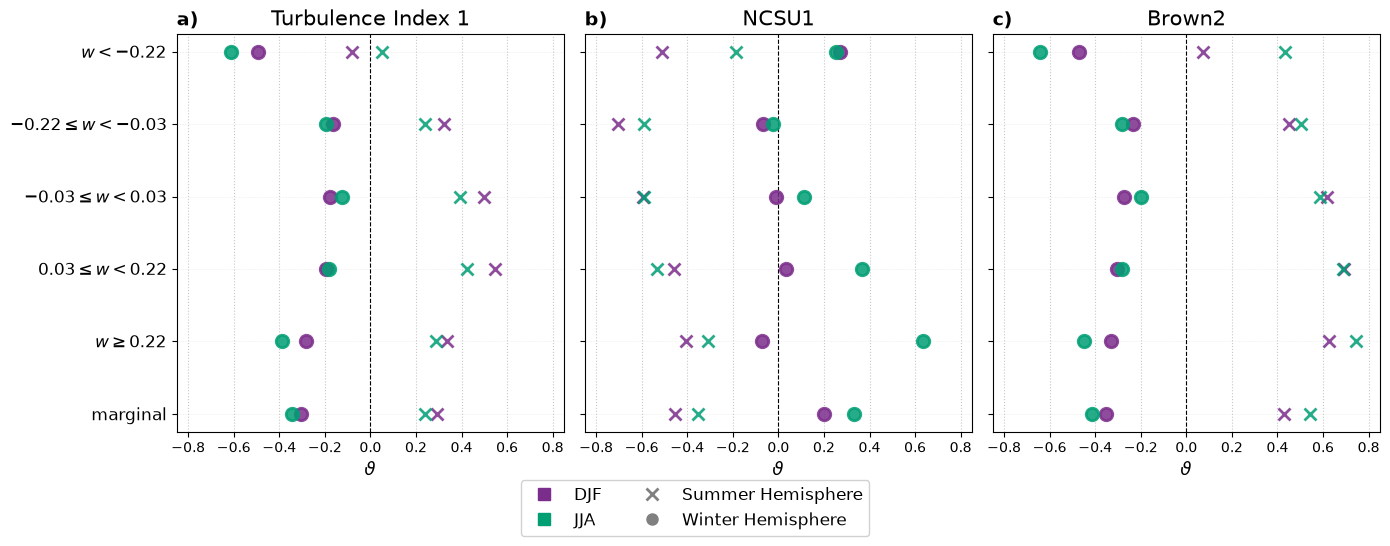

In [ ]:
condition_labels = {
    "w<-0.22": r"$w < -0.22$",
    "-0.22<=w<-0.03": r"$-0.22 \leq w < -0.03$",
    "-0.03<=w<0.03": r"$-0.03 \leq w < 0.03$",
    "0.03<=w<0.22": r"$0.03 \leq w < 0.22$",
    "w>=0.22": r"$w \geq 0.22$",
    "marginal": "marginal",
}

season_hemi_to_period = {
    ("DJF", "NH"): "winter",
    ("DJF", "SH"): "summer",
    ("JJA", "NH"): "summer",
    ("JJA", "SH"): "winter",
}

HEMI_MARKERS = {
    "NH": "x",  # summer/winter marker: x for NH
    "SH": "o",  # summer/winter marker: o for SH
}

MARKER_SIZE = 9
MARKER_LW = 2
CRITERIA_LABELS = {"ti1": "Turbulence Index 1", "brown2": "Brown2", "ncsu1": "NCSU1"}

n_criteria = len(criteria)

PERIOD_MARKERS = {
    "summer": "x",
    "winter": "o",
}
SEASON_COLOURS = {
    "DJF": "#7B2D8B",  # purple
    "JJA": "#009E73",  # green
}

combinations = [
    ("DJF", "NH"),
    ("DJF", "SH"),
    ("JJA", "NH"),
    ("JJA", "SH"),
]

all_values = da.values.ravel()
x_min = np.floor(all_values.min() * 10) / 10 - 0.05
x_max = np.ceil(all_values.max() * 10) / 10 + 0.05

fig, axes = plt.subplots(
    nrows=1,
    ncols=n_criteria,
    figsize=(14, 5),
    sharey=True,
    sharex=True,
    layout="tight",
)

y_positions = np.arange(len(conditions))

combinations = [
    ("DJF", "NH"),
    ("DJF", "SH"),
    ("JJA", "NH"),
    ("JJA", "SH"),
]

for ci, (crit, ax) in enumerate(zip(criteria, axes)):
    for season, hemi in combinations:
        period = season_hemi_to_period[(season, hemi)]
        values = da.sel(season=season, hemisphere=hemi, diagnostic=crit).values

        ax.plot(
            values,
            y_positions,
            linestyle="none",
            marker=PERIOD_MARKERS[period],
            color=SEASON_COLOURS[season],
            markersize=MARKER_SIZE,
            markeredgewidth=MARKER_LW,
            alpha=0.85,
            zorder=3,
        )

    ax.axvline(0, color="black", linewidth=0.8, linestyle="--", zorder=2)
    ax.set_title(CRITERIA_LABELS[crit], fontsize=15)
    ax.set_title(f"{get_panel_letter(ci)})", loc="left", fontweight="bold", fontsize=14)
    ax.set_xlabel(r"$\vartheta$", fontsize=13)
    ax.set_xlim(x_min, x_max)
    ax.grid(axis="x", linestyle=":", linewidth=0.8, alpha=0.7)
    ax.grid(axis="y", linestyle=":", linewidth=0.4, alpha=0.4)
    ax.set_axisbelow(True)

    if ci == 0:
        ax.set_yticks(y_positions)
        ax.set_yticklabels(
            [condition_labels[c] for c in conditions],
            fontsize=12,
        )
    else:
        ax.set_yticks(y_positions)

legend_elements = [
    mlines.Line2D(
        [],
        [],
        color=SEASON_COLOURS["DJF"],
        marker="s",
        linestyle="none",
        markersize=8,
        label="DJF",
    ),
    mlines.Line2D(
        [],
        [],
        color=SEASON_COLOURS["JJA"],
        marker="s",
        linestyle="none",
        markersize=8,
        label="JJA",
    ),
    mlines.Line2D(
        [],
        [],
        color="grey",
        marker="x",
        linestyle="none",
        markersize=8,
        markeredgewidth=2,
        label="Summer Hemisphere",
    ),
    mlines.Line2D(
        [],
        [],
        color="grey",
        marker="o",
        linestyle="none",
        markersize=8,
        label="Winter Hemisphere",
    ),
]

legend = fig.legend(
    handles=legend_elements,
    loc="lower center",
    ncol=2,
    fontsize=12,
    framealpha=0.9,
    bbox_to_anchor=(0.5, -0.10),
)


plt.savefig("vartheta.pdf", bbox_inches="tight")
plt.show()

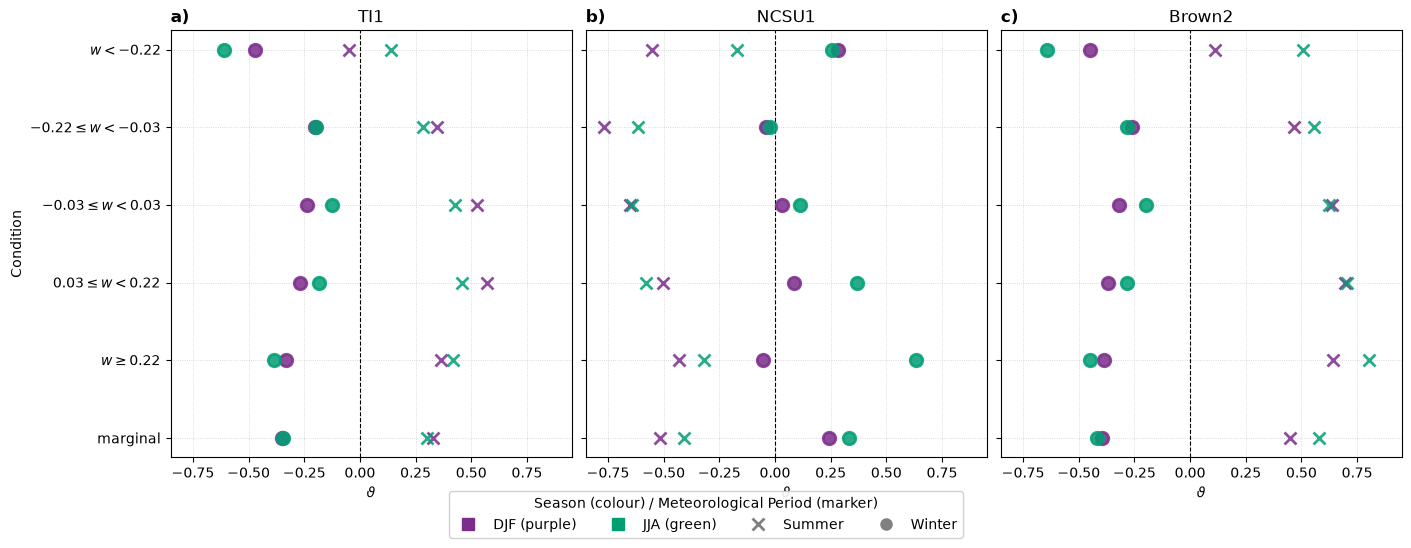

In [ ]:
all_values = da_30.values.ravel()
x_min = np.floor(all_values.min() * 10) / 10 - 0.05
x_max = np.ceil(all_values.max() * 10) / 10 + 0.05

fig, axes = plt.subplots(
    nrows=1,
    ncols=n_criteria,
    figsize=(14, 5),
    sharey=True,
    sharex=True,
    layout="constrained",
)

y_positions = np.arange(len(conditions))

combinations = [
    ("DJF", "NH"),
    ("DJF", "SH"),
    ("JJA", "NH"),
    ("JJA", "SH"),
]

for ci, (crit, ax) in enumerate(zip(criteria, axes)):
    for season, hemi in combinations:
        period = season_hemi_to_period[(season, hemi)]
        values = da_30.sel(season=season, hemisphere=hemi, diagnostic=crit).values

        ax.plot(
            values,
            y_positions,  # no offset — all on the same row
            linestyle="none",
            marker=PERIOD_MARKERS[period],
            color=SEASON_COLOURS[season],
            markersize=MARKER_SIZE,
            markeredgewidth=MARKER_LW,
            alpha=0.85,
            zorder=3,
        )

    ax.axvline(0, color="black", linewidth=0.8, linestyle="--", zorder=2)
    ax.set_title(CRITERIA_LABELS[crit])
    ax.set_title(f"{get_panel_letter(ci)})", loc="left", fontweight="bold")
    ax.set_xlabel(r"$\vartheta$")
    ax.set_xlim(x_min, x_max)
    ax.grid(axis="x", linestyle=":", linewidth=0.6, alpha=0.6)
    ax.grid(axis="y", linestyle=":", linewidth=0.6, alpha=0.6)
    ax.set_axisbelow(True)

    if ci == 0:
        ax.set_yticks(y_positions)
        ax.set_yticklabels(
            [condition_labels[c] for c in conditions],
        )
        ax.set_ylabel("Condition")
    else:
        ax.set_yticks(y_positions)

legend_elements = [
    mlines.Line2D(
        [],
        [],
        color=SEASON_COLOURS["DJF"],
        marker="s",
        linestyle="none",
        markersize=8,
        label="DJF (purple)",
    ),
    mlines.Line2D(
        [],
        [],
        color=SEASON_COLOURS["JJA"],
        marker="s",
        linestyle="none",
        markersize=8,
        label="JJA (green)",
    ),
    mlines.Line2D(
        [],
        [],
        color="grey",
        marker="x",
        linestyle="none",
        markersize=8,
        markeredgewidth=2,
        label="Summer",
    ),
    mlines.Line2D(
        [], [], color="grey", marker="o", linestyle="none", markersize=8, label="Winter"
    ),
]

fig.legend(
    handles=legend_elements,
    loc="lower center",
    ncol=4,
    framealpha=0.9,
    title="Season (colour) / Meteorological Period (marker)",
    bbox_to_anchor=(0.5, -0.08),
)

plt.show()